<a href="https://colab.research.google.com/github/ramaraghava13/Deep-Learning-Techniques/blob/main/Deep_Learning_Techniues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Dataset
trainloader = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=transforms.ToTensor()),
    batch_size=64, shuffle=True)

# Model (MLP)
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3072, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
)

# Loss + Optimizer (CHANGE HERE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training
for epoch in range(5):
    total_loss = 0
    for x, y in trainloader:
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

100%|██████████| 170M/170M [00:05<00:00, 29.1MB/s]


Epoch: 1 Loss: 1564.7508066892624
Epoch: 2 Loss: 1431.8238319158554
Epoch: 3 Loss: 1376.8370662927628
Epoch: 4 Loss: 1335.6980154514313
Epoch: 5 Loss: 1301.3931094408035


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Training shape: (45000, 3072)
Testing shape: (5000, 3072)
Iteration 1, loss = 1.94555414
Iteration 2, loss = 1.79137976
Iteration 3, loss = 1.72014744
Iteration 4, loss = 1.67818680
Iteration 5, loss = 1.64581043
Iteration 6, loss = 1.61982085
Iteration 7, loss = 1.60391612
Iteration 8, loss = 1.58214230
Iteration 9, loss = 1.57398186
Iteration 10, loss = 1.55104790
Iteration 11, loss = 1.54231308
Iteration 12, loss = 1.52285733
Iteration 13, loss = 1.50847491
Iteration 14, loss = 1.49905347
Iteration 15, loss = 1.49384104
Iteration 16, loss = 1.47856144
Iteration 17, loss = 1.46538548
Iteration 18, loss = 1.46706846
Iteration 19, loss = 1.45311732
Iteration 20, loss = 1.44456214
Iteration 21, loss = 1.44123597
Iteration 22, loss = 1.43694270
Iteration 23, loss = 1.42508334
Iteration 24, loss = 1.42096942
Iteration 25, loss = 1.41859763
Iteration 26, loss = 1.40990486
Iteration 27, loss = 1.40440626
Iteration 28, loss = 1.39167763
It

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.5140888888888889
Testing set score: 0.4672
Predicted value: 0
Actual value: 3


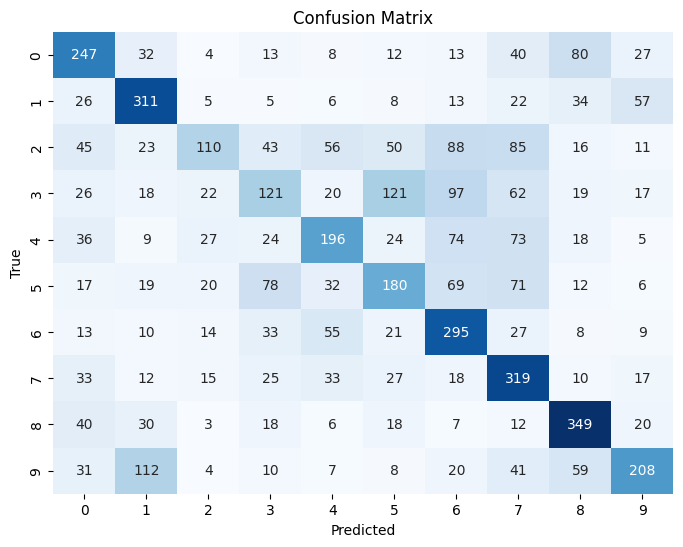

Iteration 1, loss = 3.42894617
Iteration 2, loss = 2.32730498
Iteration 3, loss = 2.32504940
Iteration 4, loss = 2.32408557
Iteration 5, loss = 2.32266557
Iteration 6, loss = 2.32267559
Iteration 7, loss = 2.32153713
Iteration 8, loss = 2.32025405
Iteration 9, loss = 2.31880768
Iteration 10, loss = 2.31840525
Iteration 11, loss = 2.31859688
Iteration 12, loss = 2.31629019
Iteration 13, loss = 2.31631435
Iteration 14, loss = 2.31569040
Iteration 15, loss = 2.31558052
Iteration 16, loss = 2.31519237
Iteration 17, loss = 2.31430453
Iteration 18, loss = 2.31438920
Iteration 19, loss = 2.31452340
Iteration 20, loss = 2.31388627
Iteration 21, loss = 2.31331779
Iteration 22, loss = 2.31329515
Iteration 23, loss = 2.31215981
Iteration 24, loss = 2.31148328
Iteration 25, loss = 2.31237620
Iteration 26, loss = 2.31138857
Iteration 27, loss = 2.31101977
Iteration 28, loss = 2.31110716
Iteration 29, loss = 2.31016781
Iteration 30, loss = 2.31047416


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score (MLP2): 0.09993333333333333
Testing set score (MLP2): 0.1006


In [ ]:
# =========================
# Load CIFAR-10 dataset
# =========================
from tensorflow.keras.datasets import cifar10

(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

# =========================
# Normalize data
# =========================
X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0

# =========================
# Flatten images (32x32x3 -> 3072)
# =========================
X_train_full = X_train_full.reshape(-1, 32*32*3)
X_test_full  = X_test_full.reshape(-1, 32*32*3)

# Convert labels to 1D
y_train_full = y_train_full.flatten()
y_test_full  = y_test_full.flatten()

# =========================
# Train-validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# =========================
# Train MLP Classifier
# =========================
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=30,
    verbose=1,
    random_state=1
)

mlp.fit(X_train, y_train)

# =========================
# Accuracy
# =========================
print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

# =========================
# Test single sample
# =========================
index = 100
sample = X_test[index].reshape(1, 3072)

prediction = mlp.predict(sample)[0]

print("Predicted value:", prediction)
print("Actual value:", y_test[index])

# =========================
# Confusion Matrix
# =========================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = mlp.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# =========================
# MLP with different learning rate
# =========================
mlp2 = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=30,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)

mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))

In [ ]:
mlp3 = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=30,
    verbose=1,
    random_state=1,
    learning_rate_init=0.005
)

mlp3.fit(X_train, y_train)
print("Training set score (MLP2):", mlp3.score(X_train, y_train))
print("Testing set score (MLP2):", mlp3.score(X_test, y_test))

Iteration 1, loss = 2.43000278
Iteration 2, loss = 2.10655724
Iteration 3, loss = 2.08529421
Iteration 4, loss = 2.07616316
Iteration 5, loss = 2.07423471
Iteration 6, loss = 2.06939151
Iteration 7, loss = 2.07005681
Iteration 8, loss = 2.06198454
Iteration 9, loss = 2.06280212
Iteration 10, loss = 2.06152114
Iteration 11, loss = 2.05873623
Iteration 12, loss = 2.05233097
Iteration 13, loss = 2.05290602
Iteration 14, loss = 2.05753416
Iteration 15, loss = 2.05110854
Iteration 16, loss = 2.04671173
Iteration 17, loss = 2.05048143
Iteration 18, loss = 2.05007999
Iteration 19, loss = 2.04806603
Iteration 20, loss = 2.04548663
Iteration 21, loss = 2.04960609
Iteration 22, loss = 2.04179914
Iteration 23, loss = 2.04060498
Iteration 24, loss = 2.04226174
Iteration 25, loss = 2.03651482
Iteration 26, loss = 2.00376615
Iteration 27, loss = 1.96441528
Iteration 28, loss = 1.95604533
Iteration 29, loss = 1.94666293
Iteration 30, loss = 1.94796992


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score (MLP2): 0.25951111111111114
Testing set score (MLP2): 0.2506


##OPTIMIZATION TECHNIQUES

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def create_model():
    model = Sequential([
        Dense(100, activation='relu', input_shape=(3072,)),
        Dense(10, activation='softmax')
    ])
    return model

SGD

In [ ]:
from tensorflow.keras.optimizers import SGD

model = create_model()
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3018 - loss: 1.9510
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3692 - loss: 1.7914
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3939 - loss: 1.7237
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4093 - loss: 1.6773
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4258 - loss: 1.6406
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4372 - loss: 1.6099
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4454 - loss: 1.5866
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4529 - loss: 1.5645
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4604 - loss: 1.5433
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4665 - loss: 1.5262
Training Accuracy: 0.37942221760749817
Testing Accuracy: 0.35499998927116394


Batch Gradient Descent

In [ ]:
model = create_model()
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=len(X_train))
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0910 - loss: 2.4273
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0827 - loss: 2.3499
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0932 - loss: 2.3327
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1032 - loss: 2.3218
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1110 - loss: 2.3137
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1166 - loss: 2.3069
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1214 - loss: 2.3008
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1257 - loss: 2.2951
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1315 - loss: 2.2899
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1358 - loss: 2.2849
Training Accuracy: 0.14042222499847412
Testing Accuracy: 0.1451999992132187


Mini batch gradient descent

In [ ]:
model = create_model()
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2951 - loss: 1.9492
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3716 - loss: 1.7896
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3946 - loss: 1.7241
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4125 - loss: 1.6744
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4250 - loss: 1.6378
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4388 - loss: 1.6079
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4471 - loss: 1.5805
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4548 - loss: 1.5590
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4617 - loss: 1.5401
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4690 - loss: 1.5226
Training Accuracy: 0.46700000762939453
Testing Accuracy: 0.4309999942779541


SGD with Momentum

In [ ]:
model = create_model()
model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3202 - loss: 1.8771
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3735 - loss: 1.7440
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3946 - loss: 1.6879
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4053 - loss: 1.6614
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4220 - loss: 1.6243
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4300 - loss: 1.5957
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4382 - loss: 1.5815
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4446 - loss: 1.5640
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4464 - loss: 1.5553
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4538 - loss: 1.5373
Training Accuracy: 0.4652888774871826
Testing Accuracy: 0.4325999915599823


SGD with Momentum+Nestrov

In [ ]:
model = create_model()
model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3440 - loss: 1.8312
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4038 - loss: 1.6751
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4273 - loss: 1.6120
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4437 - loss: 1.5680
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4548 - loss: 1.5390
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4633 - loss: 1.5118
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4679 - loss: 1.4968
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4796 - loss: 1.4742
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4816 - loss: 1.4584
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4885 - loss: 1.4478
Training Accuracy: 0.4954666793346405
Testing Accuracy: 0.45159998536109924


Adagrad

In [ ]:
from tensorflow.keras.optimizers import Adagrad

model = create_model()
model.compile(optimizer=Adagrad(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3101 - loss: 1.9172
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3863 - loss: 1.7403
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4094 - loss: 1.6722
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4302 - loss: 1.6269
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4390 - loss: 1.5925
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4524 - loss: 1.5635
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4603 - loss: 1.5400
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4662 - loss: 1.5194
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4735 - loss: 1.5031
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4831 - loss: 1.4858
Training Accuracy: 0.458688884973526
Testing Accuracy: 0.42800000309944153


RMSProp

In [ ]:
from tensorflow.keras.optimizers import RMSprop

model = create_model()
model.compile(optimizer=RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.2599 - loss: 2.0467
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3397 - loss: 1.8446
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3643 - loss: 1.7829
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3790 - loss: 1.7432
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3926 - loss: 1.7109
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3998 - loss: 1.6834
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4075 - loss: 1.6645
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4136 - loss: 1.6467
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4200 - loss: 1.6293
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4259 - loss: 1.6166
Training Accuracy: 0.3877111077308655
Testing Accuracy: 0.36039999127388


Adadelta

In [ ]:
from tensorflow.keras.optimizers import Adadelta

model = create_model()
model.compile(optimizer=Adadelta(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1281 - loss: 2.3198
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1709 - loss: 2.2321
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2038 - loss: 2.1877
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2275 - loss: 2.1516
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2459 - loss: 2.1201
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2589 - loss: 2.0951
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2678 - loss: 2.0738
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2769 - loss: 2.0551
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2833 - loss: 2.0388
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2888 - loss: 2.0243
Training Accuracy: 0.29295554757118225
Testing Accuracy: 0.28679999709129333


Adam

In [ ]:
from tensorflow.keras.optimizers import Adam

model = create_model()
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64)
# Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2690 - loss: 1.9819
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3378 - loss: 1.8430
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3544 - loss: 1.8038
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3621 - loss: 1.7848
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3685 - loss: 1.7693
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3723 - loss: 1.7580
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3778 - loss: 1.7471
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3764 - loss: 1.7448
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3798 - loss: 1.7410
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3826 - loss: 1.7311
Training Accuracy: 0.39008888602256775
Testing Accuracy: 0.36719998717308044
